In [1]:
%load_ext autoreload
%autoreload 2

from modules.data_services.data_utils import load_btc_benchmark
from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
from modules.performance.strategy import Strategy

In [2]:
interval = "1h"
fee_rate = 0.0005
initial_cash = 100000
risk_free_rate = 0

ticker_x = "ETHUSDT"
ticker_y = "UNIUSDT"

test_beta_calculation_start = "2024-01-01"
test_start = "2024-02-01"
test_end = "2024-03-01"

entry_threshold = 1.144
exit_threshold = 0.292
stop_loss = 2.34
rolling_window = 84

In [3]:
bt_1 = Strategy(
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    start=test_beta_calculation_start,
    end=test_end,
    interval=interval,
    fee_rate=fee_rate,
    initial_cash=initial_cash,
    risk_free_rate_annual=risk_free_rate,
    source="log",
    beta_hedge=None,
)

result_1 = bt_1.run_strategy(
    rolling_window=rolling_window,
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    stop_loss=stop_loss,
    test_start=test_start,
    test_end=test_end,
    beta_calculation_start=test_beta_calculation_start,
)

In [4]:
result_1.data

,ETHUSDT,UNIUSDT,z_score,beta,entry_thr,exit_thr,sl_thr,q_x,q_y,w_x,w_y,signal,position,total_return,total_fees,net_return,total_return_pct,net_return_pct
open_time,,,,,,,,,,,,,,,,,,
2024-02-01 00:00:00,2283.59,6.021,0.824571,1.0,1.144,0.292,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 01:00:00,2245.19,5.900,0.434286,1.0,1.144,0.292,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 02:00:00,2260.50,5.999,0.869592,1.0,1.144,0.292,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 03:00:00,2257.21,5.992,-0.376746,1.0,1.144,0.292,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 04:00:00,2262.77,6.001,-0.40022,1.0,1.144,0.292,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-29 20:00:00,3393.99,11.524,-0.925345,1.0,1.144,0.292,2.952074,14.837324,-4401.021037,0.5,0.5,0.0,1.0,36045.103000,1470.134147,34574.968852,0.360451,0.345750
2024-02-29 21:00:00,3347.74,11.357,-0.986743,1.0,1.144,0.292,2.952074,14.837324,-4401.021037,0.5,0.5,0.0,1.0,36093.847297,1470.134147,34623.713150,0.360938,0.346237
2024-02-29 22:00:00,3322.61,10.977,-0.990957,1.0,1.144,0.292,2.952074,14.837324,-4401.021037,0.5,0.5,0.0,1.0,37393.373350,1470.134147,35923.239202,0.373934,0.359232


In [5]:
result_1.stats

,gross,net
metric,,
total_return,0.3701,0.3549
cagr,51.3064,44.4658
volatility,0.0105,0.0106
volatility_annual,0.9820,0.9924
max_drawdown,-0.0804,-0.0838
win_count,13.0000,13.0000
lose_count,2.0000,2.0000
win_rate,0.8667,0.8667
max_win,0.2405,0.2394


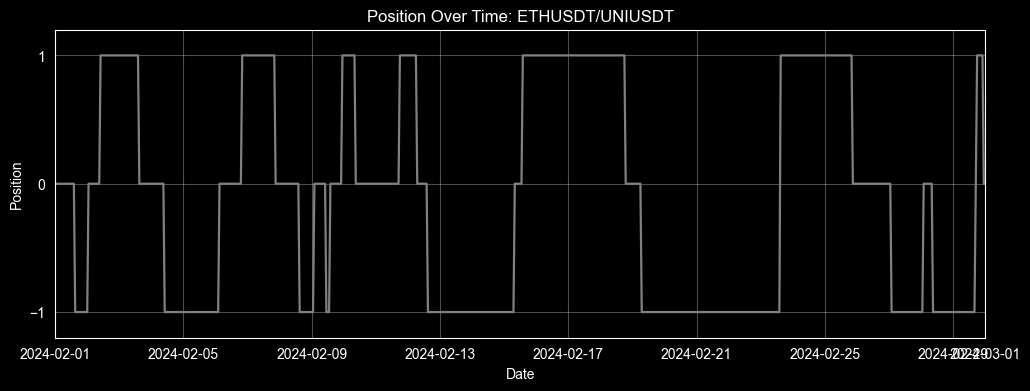

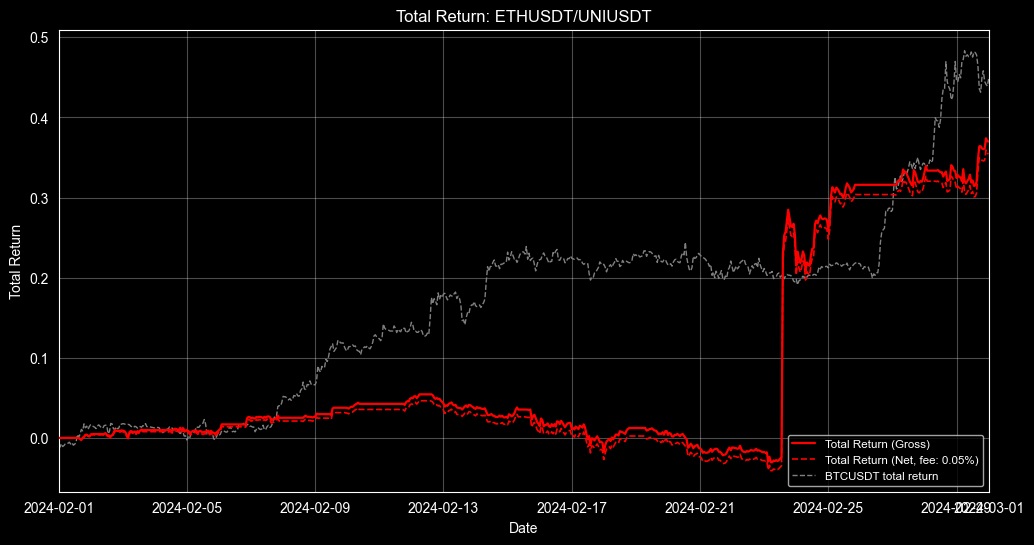

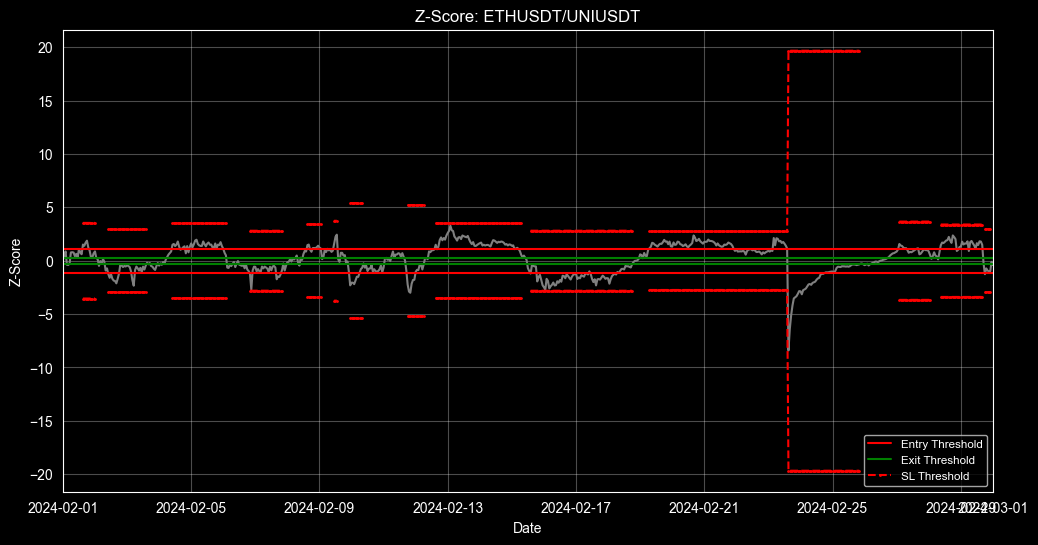

In [6]:
plot_positions(result_1, show=True)
btc_data = load_btc_benchmark(
    test_start=test_start,
    test_end=test_end,
    interval=interval,
)
plot_pnl(result_1, btc_data, show=True)
plot_zscore(result_1, show=True, sl_thr=True)

In [7]:
# result_1.data